# NDVI - Florianópolis (Sentinel-2)

Este notebook realiza:
- Leitura das bandas B04 (Red) e B08 (NIR)
- Cálculo do NDVI
- Geração de mapa
- Geração de histograma
- Salvamento como GeoTIFF

Região: Florianópolis - SC
Satélite: Sentinel-2 L2A
Resolução: 10m


In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Caminhos das bandas (já configurados)
red_path = "src/T22JGQ_20260217T132231_B04_10m.jp2"
nir_path = "src/T22JGQ_20260217T132231_B08_10m.jp2"

In [3]:
# Abrir bandas
with rasterio.open(red_path) as red_src:
    red = red_src.read(1).astype(float)
    profile = red_src.profile

with rasterio.open(nir_path) as nir_src:
    nir = nir_src.read(1).astype(float)

print("Bandas carregadas com sucesso!")

Bandas carregadas com sucesso!


In [5]:
# Calcular NDVI
ndvi = (nir - red) / (nir + red + 1e-10)

# Ajustar perfil para salvar como GeoTIFF
out_profile = profile.copy()
out_profile.update(
    driver="GTiff",
    dtype=rasterio.float32,
    count=1,
    compress="deflate"
)

# Remover configs que podem vir do JP2 e quebrar o GeoTIFF
for k in ["tiled", "blockxsize", "blockysize", "interleave"]:
    out_profile.pop(k, None)

with rasterio.open("src/ndvi_florianopolis.tif", "w", **out_profile) as dst:
    dst.write(ndvi.astype(rasterio.float32), 1)

print("NDVI salvo como GeoTIFF em src/ndvi_florianopolis.tif")

NDVI salvo como GeoTIFF em src/ndvi_florianopolis.tif


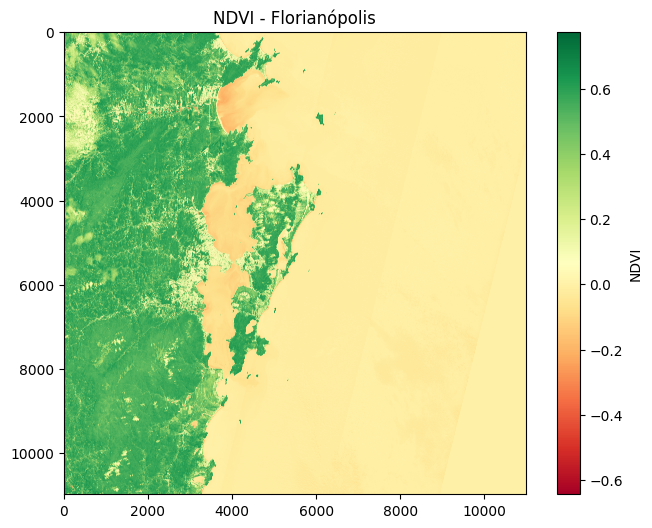

In [6]:
# Gerar mapa NDVI
plt.figure(figsize=(8,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title("NDVI - Florianópolis")
plt.savefig("src/ndvi_florianopolis.png")
plt.show()

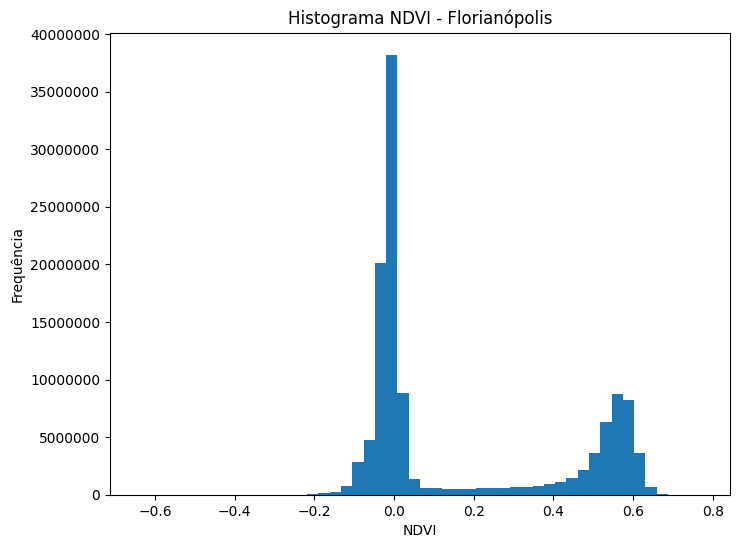

In [9]:
# Gerar histograma
plt.figure(figsize=(8,6))
plt.hist(ndvi.flatten(), bins=50)
plt.title("Histograma NDVI - Florianópolis")
plt.xlabel("NDVI")
plt.ylabel("Frequência")
plt.savefig("src/histograma_florianopolis.png")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [8]:
import numpy as np

valid = ndvi[np.isfinite(ndvi)]
print("min:", float(np.nanmin(valid)))
print("max:", float(np.nanmax(valid)))
print("mean:", float(np.nanmean(valid)))
print("std:", float(np.nanstd(valid)))

# Percentual de pixels por faixa (opcional, mas excelente)
faixas = {
    "< 0 (água/não vegetado)": np.mean(valid < 0),
    "0 a 0.2 (solo/urbano)": np.mean((valid >= 0) & (valid < 0.2)),
    "0.2 a 0.4 (vegetação baixa)": np.mean((valid >= 0.2) & (valid < 0.4)),
    ">= 0.4 (vegetação moderada/alta)": np.mean(valid >= 0.4),
}
for k,v in faixas.items():
    print(k, ":", round(float(v*100), 2), "%")

min: -0.6427835405646724
max: 0.7723923366628396
mean: 0.16812610859249877
std: 0.26016525209911506
< 0 (água/não vegetado) : 42.99 %
0 a 0.2 (solo/urbano) : 23.2 %
0.2 a 0.4 (vegetação baixa) : 3.88 %
>= 0.4 (vegetação moderada/alta) : 29.93 %
